# FraudRadar-AU: Data Preparation
## Member 1 Responsibility
This notebook covers:
1. Synthetic Australian-style product listing data generation
2. Kaggle Fraudulent E-Commerce Transactions dataset preprocessing
3. Data standardisation for all team members
4. Baseline model (Logistic Regression + Rule-Based keyword filtering)

## Data Sources
- **Synthetic data**: Generated based on Scamwatch 2024 scam patterns
- **Real-world data**: [Kaggle Fraudulent E-Commerce Transactions](https://www.kaggle.com/datasets/shriyashjagtap/fraudulent-e-commerce-transactions)

In [2]:
!pip install python-docx pandas numpy matplotlib seaborn scikit-learn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from docx import Document
import random
import re
import os

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, 
                             classification_report, confusion_matrix)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
# Load Scamwatch document
doc = Document('../data/synthetic/Scam_alert.docx')
full_text = ' '.join([para.text for para in doc.paragraphs])
print(f"Document loaded successfully!")
print(f"Total characters: {len(full_text)}")

Document loaded successfully!
Total characters: 21128


### Step 1.1: Define Australian Scam Signals
Based on patterns identified in the Scamwatch 2024 official publications.

In [7]:
# Define scam signals based on Scamwatch documentation
scam_signals = {
    'urgency': [
        'urgent', 'must go today', 'quick sale', 
        'limited time', 'selling fast', 'asap',
        'must sell', 'today only', 'going cheap'
    ],
    'payment': [
        'cash only', 'bank transfer only', 'payid only',
        'no credit card', 'money order', 'bitcoin only'
    ],
    'no_returns': [
        'no returns', 'no refunds', 'as is',
        'no warranty', 'sold as seen', 'final sale'
    ],
    'pressure': [
        'first come first served', 'many interested',
        'serious buyers only', 'no time wasters',
        'will not last', 'multiple offers'
    ],
    'suspicious': [
        'moving overseas', 'need quick cash',
        'no inspection', 'meet in car park',
        'cannot meet', 'will post only'
    ]
}

# Define legitimate signals
legit_signals = {
    'transparency': [
        'receipt included', 'original box',
        'happy to inspect', 'can meet at store',
        'apple store purchase', 'jb hi-fi purchase'
    ],
    'flexibility': [
        'open to offers', 'happy to negotiate',
        'can deliver', 'pick up or post',
        'paypal accepted', 'secure payment'
    ],
    'history': [
        'bought in 2023', 'bought in 2024',
        'owned for 6 months', 'well maintained',
        'barely used', 'excellent condition'
    ]
}

print("Scam signals defined successfully!")
print(f"Scam signal categories: {list(scam_signals.keys())}")
print(f"Legit signal categories: {list(legit_signals.keys())}")

Scam signals defined successfully!
Scam signal categories: ['urgency', 'payment', 'no_returns', 'pressure', 'suspicious']
Legit signal categories: ['transparency', 'flexibility', 'history']


### Step 1.2: Define Australian Product Templates
Common products targeted in Australian e-commerce scams based on Scamwatch reports.

In [8]:
# Common products in Australian e-commerce scams
products = [
    {'name': 'iPhone 15 Pro 256GB', 'market_price': 1799},
    {'name': 'iPhone 14 128GB', 'market_price': 1199},
    {'name': 'MacBook Pro M3 14-inch', 'market_price': 2999},
    {'name': 'MacBook Air M2', 'market_price': 1699},
    {'name': 'PS5 Console Bundle', 'market_price': 799},
    {'name': 'Nintendo Switch OLED', 'market_price': 539},
    {'name': 'Samsung Galaxy S24 Ultra', 'market_price': 1849},
    {'name': 'iPad Pro 12.9 inch', 'market_price': 1899},
    {'name': 'Dyson V15 Vacuum', 'market_price': 1199},
    {'name': 'Weber Q3200 BBQ', 'market_price': 699},
    {'name': 'Nike Air Jordan 1 Retro', 'market_price': 350},
    {'name': 'Yeezy Boost 350 V2', 'market_price': 450},
    {'name': 'Louis Vuitton Neverfull MM', 'market_price': 2850},
    {'name': 'Taylor Swift Eras Tour Ticket', 'market_price': 350},
    {'name': 'Bose QuietComfort 45', 'market_price': 549},
]

print("Product templates defined")
print(f"Total products: {len(products)}")
print(f"\nSample products:")
for p in products[:5]:
    print(f"  - {p['name']}: ${p['market_price']}")

Product templates defined
Total products: 15

Sample products:
  - iPhone 15 Pro 256GB: $1799
  - iPhone 14 128GB: $1199
  - MacBook Pro M3 14-inch: $2999
  - MacBook Air M2: $1699
  - PS5 Console Bundle: $799


### Step 1.3: Generate Synthetic Dataset
Generating 1,000 synthetic product listings (500 fraudulent, 500 legitimate)
based on Australian scam patterns from Scamwatch 2024.

In [13]:
random.seed(42)  # For reproducibility
data = []

# Generate fraudulent listings (label = 1)
for _ in range(4000):
    product = random.choice(products)
    
    # Scam price: 10% to 35% of market price
    price = round(product['market_price'] * random.uniform(0.10, 0.35))
    
    # Randomly combine scam signals
    urgency = random.choice(scam_signals['urgency'])
    payment = random.choice(scam_signals['payment'])
    no_return = random.choice(scam_signals['no_returns'])
    pressure = random.choice(scam_signals['pressure'])
    suspicious = random.choice(scam_signals['suspicious'])
    
    title = f"{urgency.title()}!! {product['name']} - Amazing Deal!!"
    description = (
        f"Brand new sealed box. {suspicious.title()}. "
        f"{payment.title()}. {no_return.title()}. "
        f"{pressure.title()}. Don't miss out!!"
    )
    
    data.append({
        'title': title,
        'description': description,
        'price': price,
        'market_price': product['market_price'],
        'price_ratio': round(price / product['market_price'], 2),
        'seller_days': random.randint(1, 14),
        'review_count': random.randint(0, 5),
        'label': 1
    })

# Generate legitimate listings (label = 0)
for _ in range(4000):
    product = random.choice(products)
    
    # Legit price: 60% to 90% of market price
    price = round(product['market_price'] * random.uniform(0.60, 0.90))
    
    transparency = random.choice(legit_signals['transparency'])
    flexibility = random.choice(legit_signals['flexibility'])
    history = random.choice(legit_signals['history'])
    
    title = f"{product['name']} - Good Condition"
    description = (
        f"{history.title()}. {transparency.title()}. "
        f"{flexibility.title()}. Genuine sale, no rush."
    )
    
    data.append({
        'title': title,
        'description': description,
        'price': price,
        'market_price': product['market_price'],
        'price_ratio': round(price / product['market_price'], 2),
        'seller_days': random.randint(180, 1500),
        'review_count': random.randint(1, 20),
        'label': 0
    })

# Convert to DataFrame and shuffle
df_synthetic = pd.DataFrame(data)
df_synthetic = df_synthetic.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Synthetic dataset generated!")
print(f"Total rows: {len(df_synthetic)}")
print(f"Fraudulent: {len(df_synthetic[df_synthetic.label==1])}")
print(f"Legitimate: {len(df_synthetic[df_synthetic.label==0])}")
print(f"\nSample data:")
df_synthetic.head()

Synthetic dataset generated!
Total rows: 8000
Fraudulent: 4000
Legitimate: 4000

Sample data:


,title,description,price,market_price,price_ratio,seller_days,review_count,label
0,Quick Sale!! Weber Q3200 BBQ - Amazing Deal!!,Brand new sealed box. Moving Overseas. Bitcoin Only. Final Sale. Will Not Last. Don't miss out!!,219,699,0.31,8,4,1
1,Going Cheap!! iPad Pro 12.9 inch - Amazing Deal!!,Brand new sealed box. Cannot Meet. Cash Only. No Refunds. Serious Buyers Only. Don't miss out!!,318,1899,0.17,3,3,1
2,Quick Sale!! Nike Air Jordan 1 Retro - Amazing Deal!!,Brand new sealed box. Moving Overseas. No Credit Card. As Is. Multiple Offers. Don't miss out!!,72,350,0.21,6,5,1
3,Selling Fast!! Taylor Swift Eras Tour Ticket - Amazing Deal!!,Brand new sealed box. No Inspection. Bitcoin Only. No Returns. Many Interested. Don't miss out!!,108,350,0.31,4,4,1
4,iPhone 14 128GB - Good Condition,"Excellent Condition. Can Meet At Store. Open To Offers. Genuine sale, no rush.",868,1199,0.72,1290,4,0


### Step 1.4: Save Synthetic Dataset

In [14]:
# Save synthetic dataset
output_path = '../data/synthetic/fraudradar_synthetic.csv'
df_synthetic.to_csv(output_path, index=False)

print(f"Saved to {output_path}")
print(f"Shape: {df_synthetic.shape}")
print(f"\nLabel distribution:")
print(df_synthetic['label'].value_counts())

Saved to ../data/synthetic/fraudradar_synthetic.csv
Shape: (8000, 8)

Label distribution:
label
1    4000
0    4000
Name: count, dtype: int64


## Step 2: Kaggle Dataset Preprocessing
Loading and cleaning the real-world Kaggle Fraudulent E-Commerce Transactions dataset.

### Step 2.1: Load and Inspect Kaggle Dataset

In [21]:
# Load new Kaggle dataset
df_kaggle2 = pd.read_csv('../data/PS_20174392719_1491204439457_log.csv', nrows=5)

print(f"Dataset loaded!")
print(f"\nColumns: {list(df_kaggle2.columns)}")
print(f"\nFirst 5 rows:")
df_kaggle2.head()

Dataset loaded!

Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [22]:
# Check dataset size and fraud distribution
df_kaggle2_full = pd.read_csv('../data/PS_20174392719_1491204439457_log.csv', 
                               usecols=['step', 'type', 'amount', 
                                       'oldbalanceOrg', 'newbalanceOrig',
                                       'oldbalanceDest', 'newbalanceDest', 
                                       'isFraud'])

print(f"Full dataset loaded!")
print(f"Shape: {df_kaggle2_full.shape}")
print(f"\nFraud distribution:")
print(df_kaggle2_full['isFraud'].value_counts())
print(f"\nFraud percentage: {df_kaggle2_full['isFraud'].mean()*100:.2f}%")
print(f"\nMissing values:")
print(df_kaggle2_full.isnull().sum())

Full dataset loaded!
Shape: (6362620, 8)

Fraud distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud percentage: 0.13%

Missing values:
step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64


### Step 2.2: Balance and Sample Kaggle Dataset
The dataset is highly imbalanced (0.13% fraud). 
We will undersample to create a balanced subset for training.

In [24]:
# Separate fraud and non-fraud
df_fraud = df_kaggle2_full[df_kaggle2_full['isFraud'] == 1]
df_legit = df_kaggle2_full[df_kaggle2_full['isFraud'] == 0]

print(f"Fraud cases: {len(df_fraud)}")
print(f"Legit cases: {len(df_legit)}")

# Undersample legitimate cases to match fraud cases
df_legit_sampled = df_legit.sample(n=8000, random_state=42)
df_fraud_sampled = df_fraud.sample(n=8000, random_state=42)

# Combine and shuffle
df_kaggle_balanced = pd.concat([df_fraud_sampled, df_legit_sampled])
df_kaggle_balanced = df_kaggle_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced dataset created!")
print(f"Shape: {df_kaggle_balanced.shape}")
print(f"\nFraud distribution:")
print(df_kaggle_balanced['isFraud'].value_counts())

Fraud cases: 8213
Legit cases: 6354407

Balanced dataset created!
Shape: (16000, 8)

Fraud distribution:
isFraud
0    8000
1    8000
Name: count, dtype: int64


### Step 2.3: Save Balanced Kaggle Dataset

In [26]:
# Save balanced Kaggle dataset
kaggle_output = '../data/processed/kaggle_balanced.csv'
df_kaggle_balanced.to_csv(kaggle_output, index=False)

print(f"Saved to {kaggle_output}")
print(f"Shape: {df_kaggle_balanced.shape}")
print(f"\nColumn names: {list(df_kaggle_balanced.columns)}")
print(f"\nSample data:")
df_kaggle_balanced.head()

Saved to ../data/processed/kaggle_balanced.csv
Shape: (16000, 8)

Column names: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']

Sample data:


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,596,PAYMENT,19493.43,315382.81,295889.38,0.00,0.00,0
1,741,TRANSFER,48442.88,48442.88,0.00,0.00,0.00,1
2,162,CASH_OUT,2934820.94,2934820.94,0.00,123944.77,3058765.71,1
3,404,TRANSFER,10000000.00,12754759.04,2754759.04,0.00,0.00,1
4,323,PAYMENT,2136.11,550023.88,547887.77,0.00,0.00,0


### Step 2.4: Exploratory Data Analysis (EDA)
Visualising the synthetic and Kaggle datasets to understand data distribution.

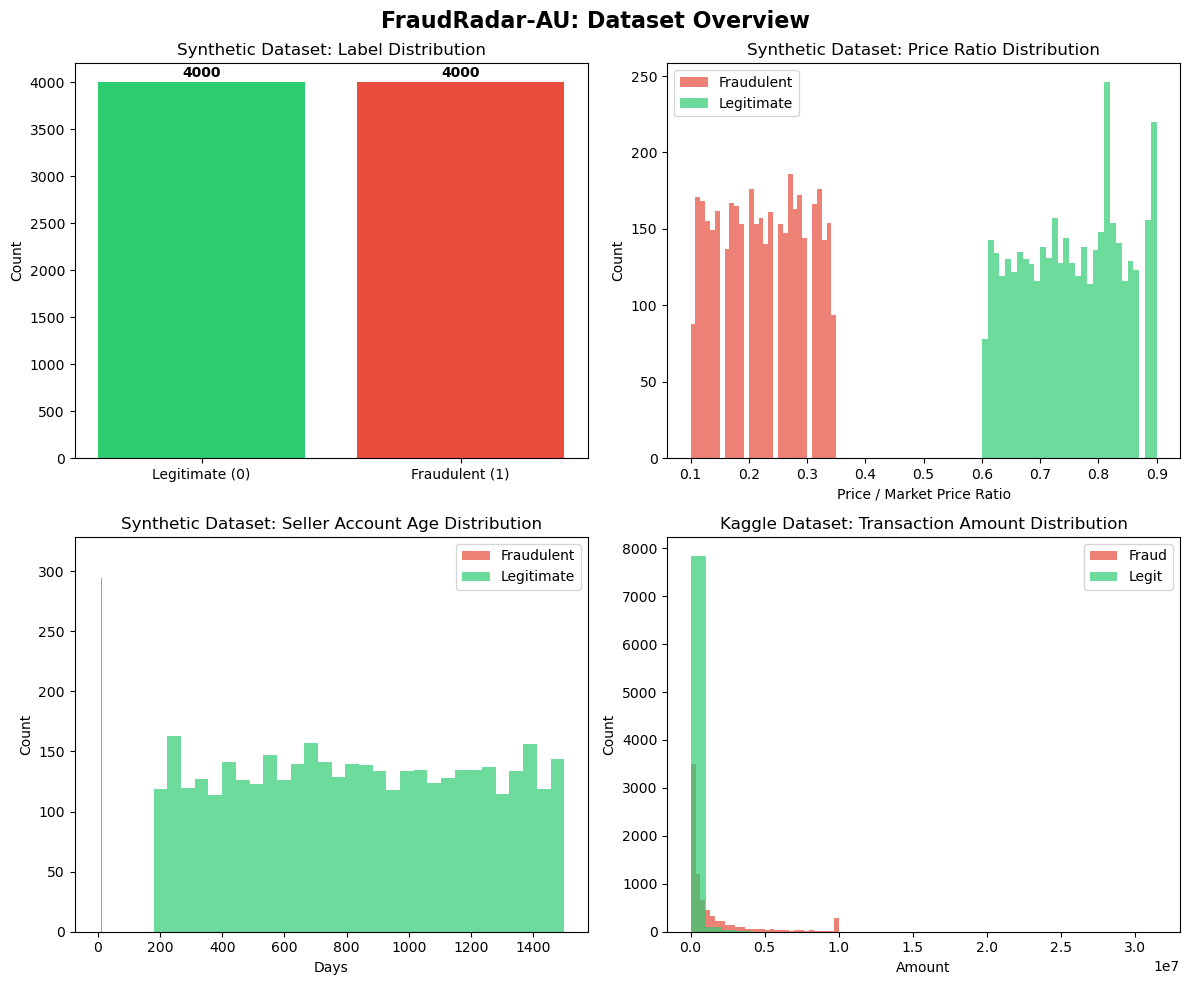

✅ EDA plots saved!


In [ ]:
# Set academic style
plt.style.use('seaborn-v0_8-whitegrid')
colors = {'fraud': '#C0392B', 'legit': '#2C3E50'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('FraudRadar-AU: Dataset Overview', 
             fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Label Distribution
bars = axes[0, 0].bar(['Legitimate (0)', 'Fraudulent (1)'], 
                       df_synthetic['label'].value_counts().sort_index().values,
                       color=[colors['legit'], colors['fraud']],
                       edgecolor='white', linewidth=0.5, width=0.5)
axes[0, 0].set_title('Synthetic Dataset: Label Distribution', 
                      fontsize=12, fontweight='bold', pad=10)
axes[0, 0].set_ylabel('Count', fontsize=10)
axes[0, 0].set_ylim(0, 5000)
for bar in bars:
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., 
                    bar.get_height() + 50,
                    f'{int(bar.get_height()):,}', 
                    ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 2: Price Ratio Distribution
axes[0, 1].hist(df_synthetic[df_synthetic['label']==1]['price_ratio'], 
                bins=25, alpha=0.8, color=colors['fraud'], 
                label='Fraudulent', edgecolor='white', linewidth=0.3)
axes[0, 1].hist(df_synthetic[df_synthetic['label']==0]['price_ratio'], 
                bins=25, alpha=0.8, color=colors['legit'], 
                label='Legitimate', edgecolor='white', linewidth=0.3)
axes[0, 1].set_title('Synthetic Dataset: Price Ratio Distribution', 
                      fontsize=12, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Price / Market Price Ratio', fontsize=10)
axes[0, 1].set_ylabel('Count', fontsize=10)
axes[0, 1].legend(fontsize=9)
axes[0, 1].axvline(x=0.5, color='gray', linestyle='--', 
                    linewidth=1, label='Threshold')

# Plot 3: Seller Account Age
axes[1, 0].hist(df_synthetic[df_synthetic['label']==0]['seller_days'], 
                bins=30, alpha=0.8, color=colors['legit'], 
                label='Legitimate', edgecolor='white', linewidth=0.3)
axes[1, 0].hist(df_synthetic[df_synthetic['label']==1]['seller_days'], 
                bins=15, alpha=0.8, color=colors['fraud'], 
                label='Fraudulent', edgecolor='white', linewidth=0.3)
axes[1, 0].set_title('Synthetic Dataset: Seller Account Age', 
                      fontsize=12, fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Account Age (Days)', fontsize=10)
axes[1, 0].set_ylabel('Count', fontsize=10)
axes[1, 0].legend(fontsize=9)

# Plot 4: Kaggle Transaction Amount (log scale)
axes[1, 1].hist(df_kaggle_balanced[df_kaggle_balanced['isFraud']==1]['amount'], 
                bins=30, alpha=0.8, color=colors['fraud'], 
                label='Fraud', edgecolor='white', linewidth=0.3)
axes[1, 1].hist(df_kaggle_balanced[df_kaggle_balanced['isFraud']==0]['amount'], 
                bins=30, alpha=0.8, color=colors['legit'], 
                label='Legitimate', edgecolor='white', linewidth=0.3)
axes[1, 1].set_title('Kaggle Dataset: Transaction Amount Distribution', 
                      fontsize=12, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Transaction Amount (Log Scale)', fontsize=10)
axes[1, 1].set_ylabel('Count', fontsize=10)
axes[1, 1].set_xscale('log')
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../results/figures/dataset_overview.png', 
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Academic style EDA plots saved!")